In [1]:
# Import packages
import os
from pathlib import Path

os.chdir(Path.cwd().parent)
project_dir = Path("/home/mcaskey/10XvParse/")

import matplotlib.pyplot as plt
from XvP_utils import plotting

analysis_name = "Analysis_4"

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

# Preprocess

In [3]:
kb_dir = project_dir / f"Data/{analysis_name}/parse/kb_python/all_out"
polyT_bcs_file = project_dir / f"Configs/{analysis_name}/parse/r1_T.txt"
rando_bcs_file = project_dir / f"Configs/{analysis_name}/parse/r1_R.txt"
replacement_bcs_file = project_dir / f"Configs/{analysis_name}/parse/replace.txt"
bc_to_wells_file = project_dir / f"Configs/{analysis_name}/parse/bcs_to_wells.txt"

In [ ]:
# load data
parse_data = plotting.init_processing('parse', kb_dir=kb_dir, data_title = "Parse", modified=True)
unmodified_data = plotting.init_processing('parse', kb_dir=kb_dir, data_title = "Parse", modified=False)

In [5]:
def get_human_mouse_counts(data):
    data.obs["human_counts"] = data.X[:,data.var_names.str.startswith("HUMAN_")].sum(axis=1)
    data.obs["mouse_counts"] = data.X[:,data.var_names.str.startswith("MOUSE_")].sum(axis=1)
    data.obs["total_counts"] = data.obs["human_counts"] + data.obs["mouse_counts"]
    data.obs["human_fraction"] = data.obs["human_counts"] / data.obs["total_counts"]
    data.obs["species"] = "doublet"
    data.obs.loc[data.obs["human_fraction"] > 0.9, "species"] = "human"
    data.obs.loc[data.obs["human_fraction"] < 0.1, "species"] = "mouse"
    return data

parse_data = get_human_mouse_counts(parse_data)
unmodified_data = get_human_mouse_counts(unmodified_data)

In [6]:
# count in polyT and randO barcodes and extract the corresponding data from the unmodified data
with open(polyT_bcs_file, 'r') as f:
    polyT_bcs = [line.strip() for line in f]
with open(rando_bcs_file, 'r') as f:
    rando_bcs = [line.strip() for line in f]

polyT_data = unmodified_data[unmodified_data.obs_names.str.endswith(tuple(polyT_bcs))]
randO_data = unmodified_data[unmodified_data.obs_names.str.endswith(tuple(rando_bcs))]

# replace randO barcodes with polyT barcodes in randO data
with open(replacement_bcs_file, 'r') as f:
    for line in f:
        rando_bc, polyT_bc = line.strip().split()
        randO_data.obs_names = randO_data.obs_names.str.replace(f"{rando_bc}$", polyT_bc[1:], regex=True)

# Add well information to the data
bc_to_wells = {}
with open(bc_to_wells_file, 'r') as f:
    for line in f:
        bc, well = line.strip().split()
        bc_to_wells[bc] = well

randO_data.obs['well'] = randO_data.obs_names.str[-8:].map(bc_to_wells)
polyT_data.obs['well'] = polyT_data.obs_names.str[-8:].map(bc_to_wells)
parse_data.obs['well'] = parse_data.obs_names.str[-8:].map(bc_to_wells)

/tmp/ipykernel_1203743/2992652321.py:24: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  polyT_data.obs['well'] = polyT_data.obs_names.str[-8:].map(bc_to_wells)


In [7]:
polyT_data.obs

,n_genes,n_counts,human_counts,mouse_counts,total_counts,human_fraction,species,well
barcode,,,,,,,,
AAACATCGAAACATCGACTCCTGC,20,20.0,9.0,11.0,20.0,0.450000,doublet,A12
AAACATCGAAACATCGACTCGTAA,17,17.0,9.0,8.0,17.0,0.529412,doublet,A10
AAACATCGAAACATCGCATACTTC,1,1.0,1.0,0.0,1.0,1.000000,human,B4
AAACATCGAAACATCGCATTTACA,19,20.0,9.0,11.0,20.0,0.450000,doublet,A9
AAACATCGAAACATCGCCCTTATA,1,1.0,0.0,1.0,1.0,0.000000,mouse,B8
...,...,...,...,...,...,...,...,...
TTCACGCATTCACGCAACTCGTAA,8,8.0,7.0,1.0,8.0,0.875000,doublet,A10
TTCACGCATTCACGCACATTTACA,11,14.0,12.0,2.0,14.0,0.857143,doublet,A9
TTCACGCATTCACGCACCTTTGCA,7,7.0,7.0,0.0,7.0,1.000000,human,A11


In [8]:
# Add polyT and randO count counts to parse data
parse_data.obs['polyT_counts'] = 0
parse_data.obs.loc[polyT_data.obs_names, 'polyT_counts'] = polyT_data.obs['n_counts']

parse_data.obs['randO_counts'] = 0
parse_data.obs.loc[randO_data.obs_names, 'randO_counts'] = randO_data.obs['n_counts']

parse_data.obs['polyT_human_counts'] = polyT_data.obs['human_counts']
parse_data.obs['randO_human_counts'] = randO_data.obs['human_counts']

parse_data.obs['polyT_human_counts'] = parse_data.obs['polyT_human_counts'].fillna(0)
parse_data.obs['randO_human_counts'] = parse_data.obs['randO_human_counts'].fillna(0)
parse_data.obs['polyT_mouse_counts'] = polyT_data.obs['mouse_counts'].fillna(0)
parse_data.obs['randO_mouse_counts'] = randO_data.obs['mouse_counts'].fillna(0)

# Parse Well Analysis

In [ ]:
def plot_species_by_well(ax, data):
    species_counts = data.obs.groupby(["well", "species"]).size().unstack(fill_value=0)
    species_counts.plot(kind="bar", stacked=True, ax=ax)
    ax.set_title("Species Composition by Well")
    ax.set_xlabel("Well")
    ax.set_ylabel("Number of Cells")
    ax.legend(title="Species")

def scatter_polyT_randO_species_counts(ax, data, species, corr=True):
    ax.scatter(data.obs[f"polyT_{species}_counts"], data.obs[f"randO_{species}_counts"], alpha=0.5)
    ax.set_xlabel(f"polyT {species} counts")
    ax.set_ylabel(f"randO {species} Counts")
    ax.set_title(f"PolyT vs RandO {species} Counts")
    if corr:
        CCC_r = plotting.ccc(data.obs[f"polyT_{species}_counts"], data.obs[f"randO_{species}_counts"])
        ax.text(0.05, 0.9, r'$\rho_C=%.2f$' % (CCC_r, ), transform=ax.transAxes, fontsize=12) 

def barnyard_plot(ax, data):
    doublet_mask = data.obs['species'] == 'doublet'
    mouse_mask = data.obs['species'] == 'mouse'
    human_mask = data.obs['species'] == 'human'
    ax.scatter(data.obs.loc[doublet_mask, 'human_counts'], data.obs.loc[doublet_mask, 'mouse_counts'], color='purple', alpha=0.5, label='Doublets')
    ax.scatter(data.obs.loc[human_mask, 'human_counts'], data.obs.loc[human_mask, 'mouse_counts'], color='blue', alpha=0.5, label='Human Singlets')
    ax.scatter(data.obs.loc[mouse_mask, 'human_counts'], data.obs.loc[mouse_mask, 'mouse_counts'], color='red', alpha=0.5, label='Mouse Singlets')
    
    ax.set_xlabel("Human Counts")
    ax.set_ylabel("Mouse Counts")
    ax.set_title("Barnyard Plot")
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.legend()


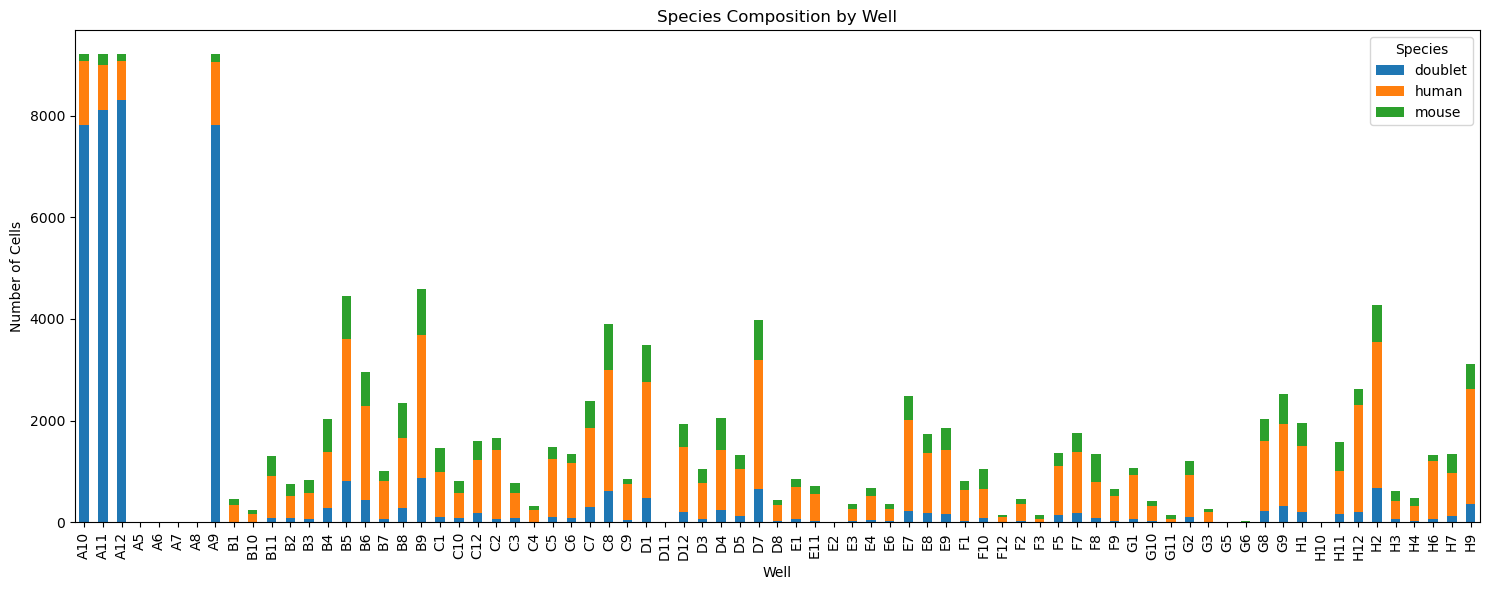

In [10]:
plt.figure(figsize=(15, 6))
plot_species_by_well(plt.gca(), parse_data)
plt.tight_layout()
plt.show()

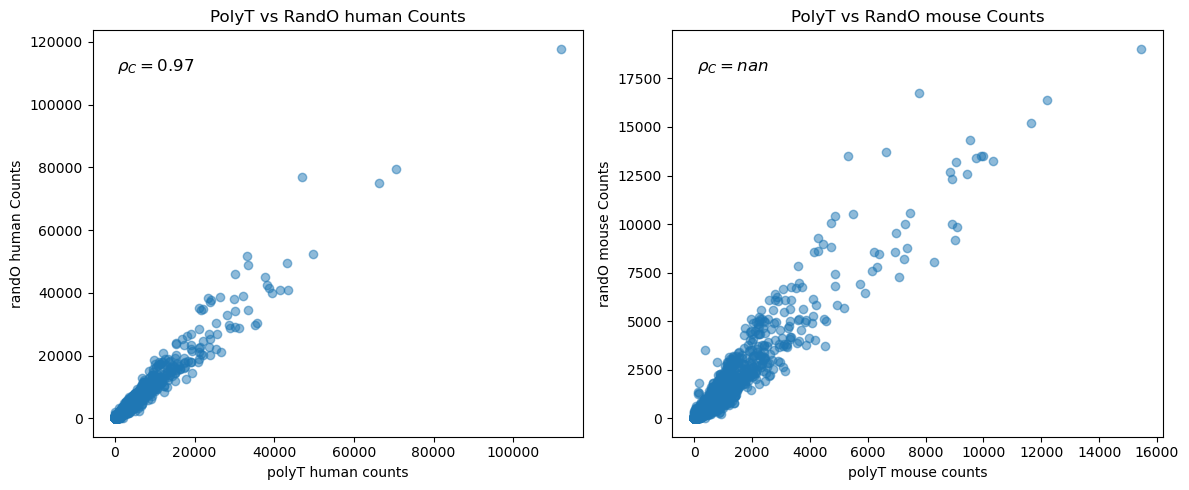

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
scatter_polyT_randO_species_counts(ax[0], parse_data, "human")
scatter_polyT_randO_species_counts(ax[1], parse_data, "mouse")
plt.tight_layout()
plt.show()

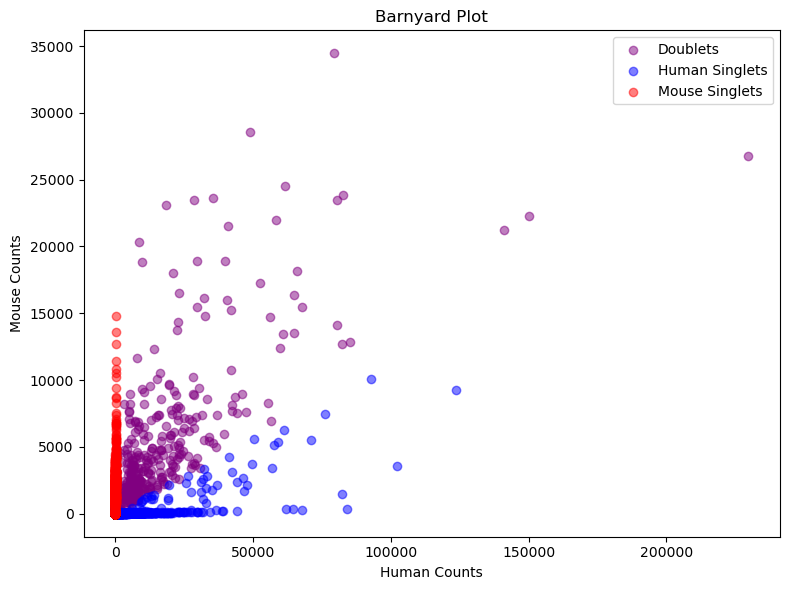

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
barnyard_plot(ax, parse_data)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

plotting.violin_by_well(ax[0], parse_data.obs)
plotting.violin_by_cell(ax[1], parse_data.obs)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

plotting.plot_by_well(ax[0], parse_data.obs)
plotting.plot_by_cell(ax[1], parse_data.obs)

plt.tight_layout()
plt.show()

2,043 cells passed the 300 UMI threshold for Parse


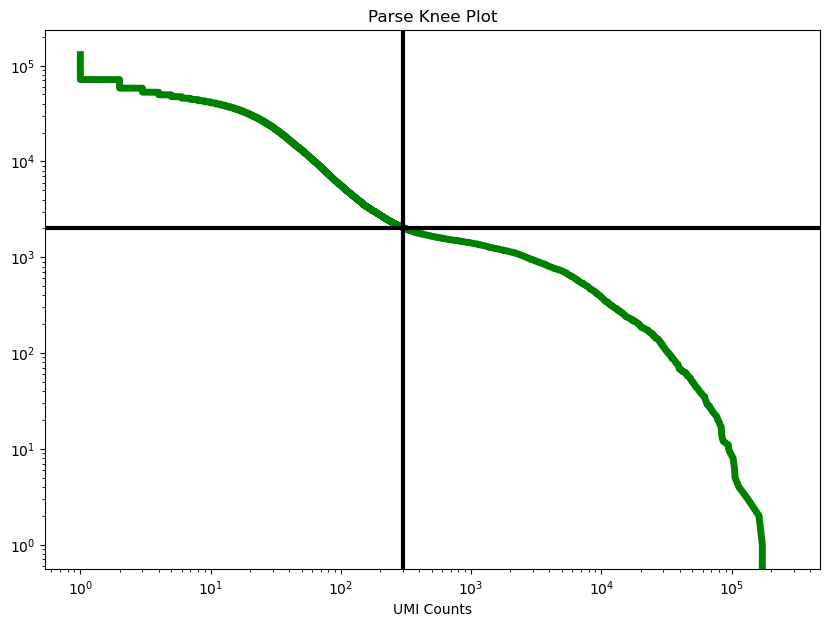

In [15]:
fig, ax = plt.subplots(figsize=(10, 7))

parse_filtered = plotting.knee_plot(ax, parse_data, cutoff = 300)
plt.show()

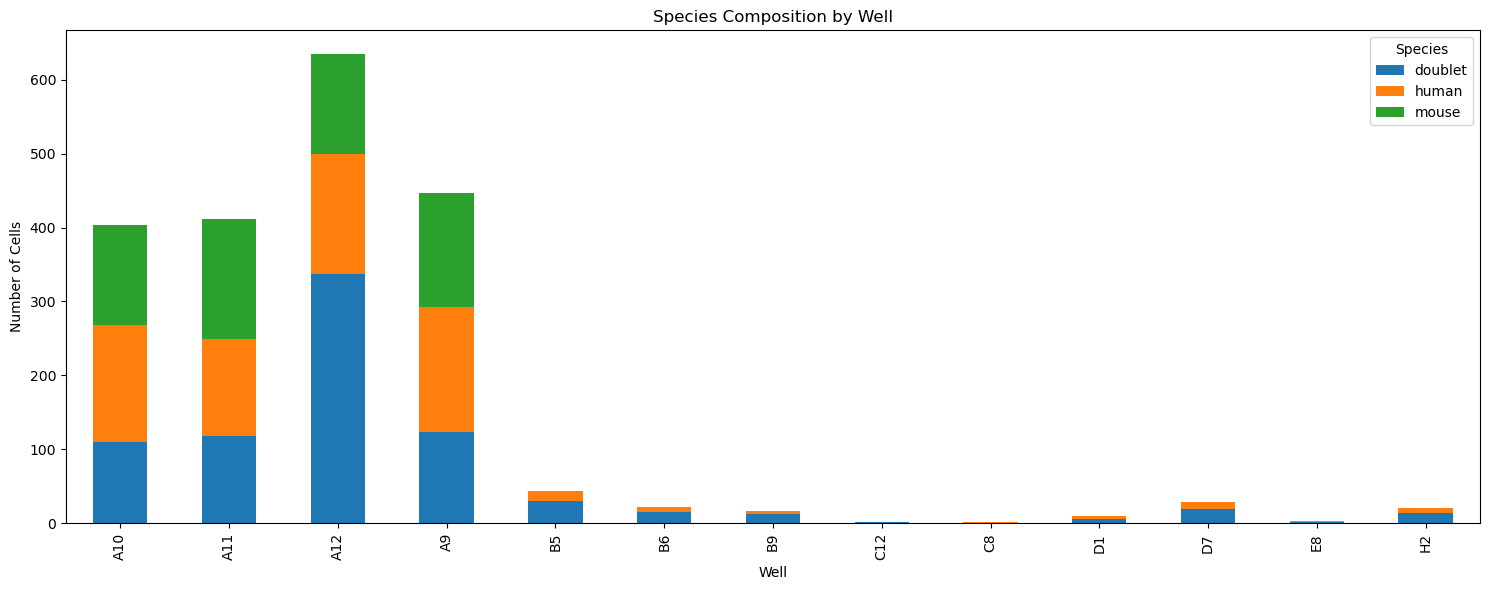

In [16]:
plt.figure(figsize=(15, 6))
plot_species_by_well(plt.gca(), parse_filtered)
plt.tight_layout()
plt.show()

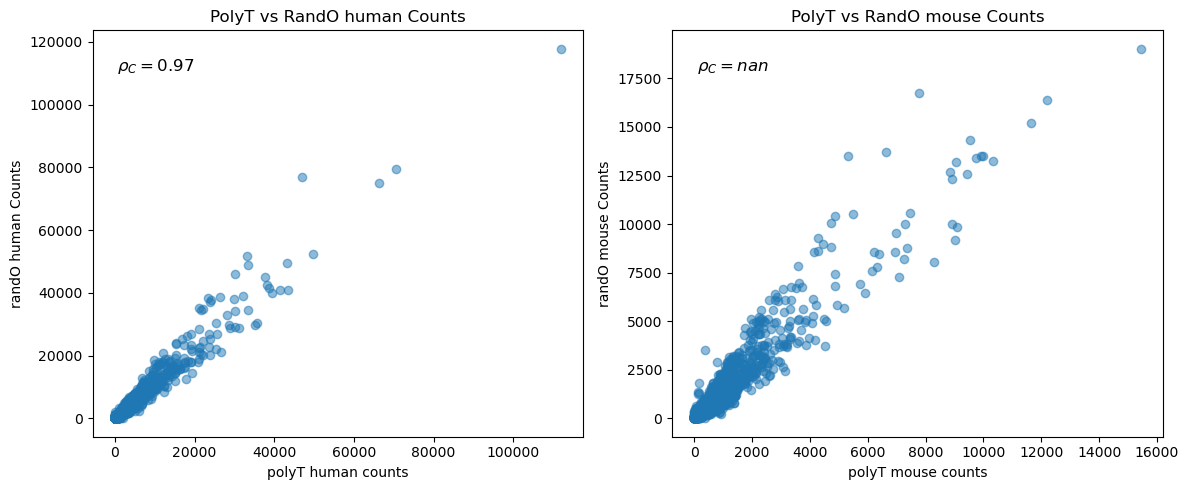

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
scatter_polyT_randO_species_counts(ax[0], parse_filtered, "human")
scatter_polyT_randO_species_counts(ax[1], parse_filtered, "mouse")
plt.tight_layout()
plt.show()

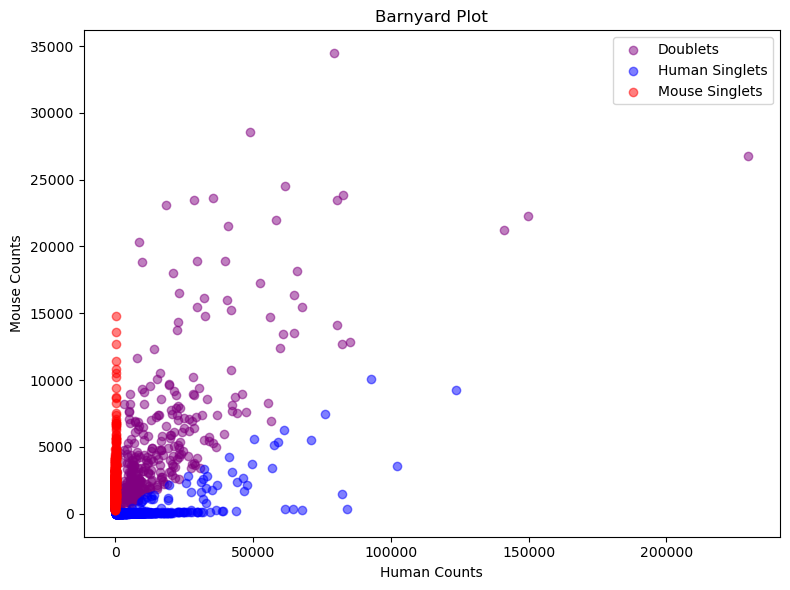

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
barnyard_plot(ax, parse_filtered)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

plotting.violin_by_well(ax[0], parse_filtered.obs)
plotting.violin_by_cell(ax[1], parse_filtered.obs)

plt.show()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

plotting.plot_by_well(ax[0], parse_filtered.obs)
plotting.plot_by_cell(ax[1], parse_filtered.obs)

plt.tight_layout()
plt.show()